# using `gcepy` for likelihood-based analysis and beyond

6 Mar 2024

Samuel D. McDermott

### imports

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt

first, I load the package that contains the definition of the log likelihood (you need to make sure that you have installed with `python setup.py install` first) with `import gcepy as gp`. Then I'll load some samplers, which operate in similar but meaningfully different ways (both of which I'll use in this notebook). Finally, I'll load the just-in-time compilation feature of jax, which is very useful, and `jax.numpy` and `numpy` in case I need them

In [2]:
import gcepy as gp

import dynesty as dn
import numpyro as nr

from jax import jit
from jax import numpy as jnp

import numpy as np
import pygtc

In [3]:
hm_lowpriors, hm_highpriors = gp.models.hm.pmin, gp.models.hm.pmax

lm_lowpriors, lm_highpriors = gp.models.lm.pmin, gp.models.lm.pmax

be aware that `jax` has strong feelings about randomness -- for more of an explanation, see https://jax.readthedocs.io/en/latest/notebooks/Common_Gotchas_in_JAX.html#random-numbers

In [4]:
import jax.random as jr
rng_key = jr.PRNGKey(0)

here is an example of how to use random number generation in practice

In [5]:
gp.lnlike('low', jr.uniform(rng_key,(5,))*(lm_highpriors[:5] - lm_lowpriors[:5]) + lm_lowpriors[:5],
          bin_no=5, ex_num=1)

Array(-2.2230745e+10, dtype=float32)

you ought to run `jax.random.split` every time you want a new random number from the same distribution: note that the first two are identical, because we reused the key

In [6]:
rng_key, rng_key_ = jr.split(rng_key)

gp.lnlike('low', jr.uniform(rng_key,(5,))*(lm_highpriors[:5] - lm_lowpriors[:5]) + lm_lowpriors[:5], bin_no=5, ex_num=1),\
gp.lnlike('low', jr.uniform(rng_key,(5,))*(lm_highpriors[:5] - lm_lowpriors[:5]) + lm_lowpriors[:5], bin_no=5, ex_num=1),\
gp.lnlike('low', jr.uniform(rng_key_,(5,))*(lm_highpriors[:5] - lm_lowpriors[:5]) + lm_lowpriors[:5], bin_no=5, ex_num=1)

(Array(-1.447981e+12, dtype=float32),
 Array(-1.447981e+12, dtype=float32),
 Array(-636932.2, dtype=float32))

In [7]:
rng_key = jr.PRNGKey(0) #"resetting" this for later

# likelihood-based analyses: a tale of three samplers

## low-dimensional model

### nested sampling with `dynesty`

First, I'll demonstrate the usage of `dynesty` in this context

It's natural to run `dynesty` first, since `dynesty` doesn't need initial values (this is because a nested sampler's goal is to explore the entire posterior space, including regions that may seem to have low likelihoods but which contain a large volume)

first of all, we have to define a "prior transform." This function is necessary because dynesty always samples from the unit cube, and it needs a way to transform these samples to the parameters of interest

In [8]:
def ptform(x, dim):
    return x*(lm_highpriors[:dim] - lm_lowpriors[:dim]) + lm_lowpriors[:dim]
jptform = jit(ptform, static_argnums=(1,))

specifying some model hyperparameters: in this notebook, we'll find the posteriors for energy bin Python-indexed-9, regarding model excess 1 (DM), which has 5 parameters

In [9]:
EBIN, EXNUM, PDIM = 9, 1, 5

first we create the sampler; this requires two callables and a declaration of the parameter space dimension. The two callables are the likelihood and the transform from the unit cube

then we run the sampler. The most meaningful hyperparameter is `dlogz`, which is a stopping criterion and roughly sets an error bar on the precision of the evidence and on the likelihood. I'm doing `dlogz=10` here, but we used `dlogz=1` for our paper

In [10]:
sampler_dn = dn.NestedSampler(lambda x: gp.lnlike('low', x, EBIN, ex_num=EXNUM),
                              lambda x: jptform(x, PDIM), PDIM, bootstrap=0)

sampler_dn.run_nested(dlogz=10)

/Users/sammcd/micromamba/envs/s4/lib/python3.12/site-packages/dynesty/dynamicsampler.py:453: RuntimeWarning: overflow encountered in cast
  cur_live_logl[not_finite] = _LOWL_VAL
9514it [00:23, 397.78it/s, +500 | bound: 82 | nc: 1 | ncall: 79523 | eff(%): 12.672 | loglstar:   -inf < -125439.148 <    inf | logz: -125461.796 +/-  0.414 | dlogz:  0.073 > 10.000]


the posterior is described in `{sampler name}.results`

`{sampler name}.results.summary()` gives the hyperparameters from the run

In [11]:
sampler_dn.results.summary()
sampler_dn.results.logz[-1], sampler_dn.results.logl[-1]

Summary
nlive: 500
niter: 9514
ncall: 79023
eff(%): 12.672
logz: -125461.796 +/-  1.747


(np.float64(-125461.79570967042), np.float64(-125439.1484375))

### NUTS implementation of HMC in `numpyro`: low-dimensional model

Now I'll run the No-U-Turn Sampler version of Hamiltonian Monte Carlo using `numpyro`.

This example does not harness the full, abstract strength of numpyro as a general probabilistic programming language. Instead, I'm just using the NUTS HMC by telling the sampler that the potential energy is equal to the negative log probability.

Again, first we create the sampler; this requires one callable and a specification of some hyperparameters. I'm choosing a small number of warmup steps, because this seems to give good results. I'm initializing this from all 0s (in the log10 of the normalizations), but you could instead use the final state of the `dynesty` run, or anywhere else you like. Initializing from 0s is a good check of the nested sampler results, however, so I think this is useful to see.

Note that `numpyro` explicitly requires the random key (mentioned above)

In [12]:
sampler_nr = nr.infer.MCMC(nr.infer.NUTS(potential_fn = lambda t: -gp.lnlike('low', t, bin_no=EBIN, ex_num=EXNUM)),
                           num_samples=10000, num_warmup=100, jit_model_args=True, chain_method='vectorized')

sampler_nr.run(rng_key, init_params = jnp.zeros(PDIM))

sample: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10100/10100 [01:13<00:00, 136.66it/s, 15 steps of size 1.35e-01. acc. prob=0.93]


the timing is similar for this model, but the cool thing about HMC/NUTS is that it does a very good job even in very high dimensions

`numpyro` does not default to keeping all samples.
Instead, only the final point is kept readily accessible, which is fine because HMC is reversible.
So we must call `{sampler name}.get_samples()` first before we can assess the properties of the posterior.
This is relevant because NUTS is not monotonically decreasing in potential energy.
So it's possible (even likely) that the final state will not be the maximum likelihood point.

In [13]:
samples_nr = sampler_nr.get_samples()

Then we have to evaluate the likelihood at every sample

In [14]:
lls_nr = jnp.array([gp.lnlike('low', x, bin_no=EBIN, ex_num=EXNUM) for x in samples_nr])

Now let's compare

In [15]:
sampler_dn.results.logl[-1], float(lls_nr.max()), float(-sampler_nr.last_state.potential_energy), int(lls_nr.argmax())

(np.float64(-125439.1484375), -125438.90625, -125439.5, 8130)

the HMC sampler found a point that was better than its final point by a small Delta log likelihood of about 1 (and better than the nested sampler by a similar amount)

### corner plots: low-dimensional models

Because we don't want to do all 14 energy bins for all 6 models of interest in this notebook, we won't make spectrum plots here (though the examples shown here are perfectly parallelizable, so any multi-core cluster you have access to will do a good job with these code snippets with minimal changes).

Instead, I'll make the corner plots.

In [16]:
names=['pi+brem', 'ICS', 'bub', 'iso', 'DM']

The `numpyro` results automatically drop the "warmup" steps, so the remaining samples can be histogrammed and plotted directly. The `dynesty` results on the other hand do not have the property of being directly proportional to the posterior (the nested sampler is trying to calculate the entire volume of the posterior manifold, not trying to satisfy the ergodic property). You can deal with this in a number of different ways. Here, I keep all of the samples but reweight them using the  `dynesty` sampler method `{results}.samples_equal()`

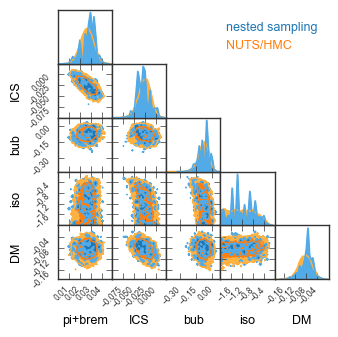

In [17]:
pygtc.plotGTC(chains = [sampler_dn.results.samples_equal(), samples_nr],
              smoothingKernel = 0.1,
#               paramRanges = [(-.35,-.25), (-.15,.05), (-1.2, .4), (-2, 0), (-.2,.2)],
              chainLabels = ['nested sampling', 'NUTS/HMC'],
              paramNames = names, #paramRanges = [list(x) for x in bounds[:-1]],
             )
# plt.savefig("/Users/sammcd/Dropbox/bs/0interviews/24/verses_6param.pdf", bbox_inches = 'tight')
plt.show()

the nested sampler results are a bit broader and less smooth, but generally these agree well

## high-dimensional model: `dynesty` vs `numpyro/NUTS`

now that you've seen how to run everything in the context of the low-dimensional, astrophysically motivated, model, I'll show how to run the high-dimensional model as well. Note that **this will not work unless you've gotten the correct template files**, which are *not* included in the github repository by default. You must email a request for these models because neither I nor my coauthors made the original models (though we do have reprojected, rebinned versions available).

again, I'm defining a prior transform, now for different (and more numerous) priors

In [18]:
alt_hm_lowpriors = jnp.array([2., 2., 2., 2., 2., 2., 2., 2., 2., -2., -2., -2., -2.,
       -2., -2., -2., -2., -2., -2., -2.])
alt_hm_highpriors = jnp.array([10., 10., 10., 10., 10., 10., 10., 10., 10., 5., 10., 10., 10.,
       10., 10., 10.,  1.,  1.,  1.,  1.])

In [19]:
def ptform_h(u, dim):
    # u = u.at[9].set((1/u[8]+1/u[9])**-1)
    x = u*(alt_hm_highpriors[:dim] - alt_hm_lowpriors[:dim]) + alt_hm_lowpriors[:dim]
    # x = x.at[9].set(jnp.log10(jnp.minimum(jnp.sum(10**x[:9]), 10**x[9])))
    return x
jptform_h = jit(ptform_h, static_argnums=(1,))

using the same energy bin but the parameter dimension increases from 5 to 19 in this model

In [21]:
EBIN, EXNUM, PDIM = 9, 1, 19

and then I run the dynamic nested sampler in the exact same way -- the only difference from the user's perspective is `gp.lnlike('low'...)` becomes `gp.lnlike('high'...)`

In [22]:
h_sampler_dn = dn.NestedSampler(lambda x: gp.lnlike('high_hard', x, EBIN, ex_num=EXNUM),
                                lambda x: jptform_h(x, PDIM), PDIM, bootstrap=0)
h_sampler_dn.run_nested(dlogz=10)

/Users/sammcd/micromamba/envs/s4/lib/python3.12/site-packages/dynesty/dynamicsampler.py:453: RuntimeWarning: overflow encountered in cast
  cur_live_logl[not_finite] = _LOWL_VAL
29632it [10:39, 46.37it/s, +500 | bound: 375 | nc: 1 | ncall: 1103352 | eff(%):  2.732 | loglstar:   -inf < -125583.141 <    inf | logz: -125647.730 +/-  1.069 | dlogz:  0.351 > 10.000]


In [23]:
h_sampler_dn.results.summary()

Summary
nlive: 500
niter: 29632
ncall: 1102852
eff(%):  2.732
logz: -125647.730 +/-  5.162


this took quite a bit longer (though still not so bad!) -- yet the evidence is much lower

In [24]:
h_sampler_dn.results.logz[-1] - sampler_dn.results.logz[-1]

np.float64(-185.93387752813578)

just to prove the goodness of the scaling in parameter dimension for HMC/NUTS, I'll run `numpyro` again as well

In [25]:
h_sampler_nr = nr.infer.MCMC(nr.infer.NUTS(potential_fn = lambda t: -gp.lnlike('high_hard', t, bin_no=EBIN, ex_num=EXNUM),
                            max_tree_depth=(10,6)),
                           num_samples = 10000, num_warmup = 100, jit_model_args=True, chain_method='vectorized')

h_sampler_nr.run(rng_key, init_params = h_sampler_dn.results.samples[-1])

sample: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10100/10100 [04:59<00:00, 33.77it/s, 21 steps of size 1.07e-02. acc. prob=0.38]


the time scaling from the low-dimensional model to the high-dimensional model is a bit better for HMC/NUTS, especially after the warmup phase

here are the corner plots:

In [26]:
h_samples_nr = h_sampler_nr.get_samples()
h_lls_nr = jnp.array([gp.lnlike('high', x, bin_no=EBIN, ex_num=EXNUM) for x in h_samples_nr])

In [27]:
h_names=['HI$_{1}$', 'HI$_{2}$', 'HI$_{3}$', 'HI$_{4}$', 'H2$_{1}$', 'H2$_{2}$',
        'H2$_{3}$', 'H2$_{4}$', 'pres', 'nres', 'ICS$_{1a}$', 'ICS$_{1b}$',
       'ICS$_{1c}$', 'ICS$_{2}$', 'ICS$_{3}$', 'ICS$_{4}$', 'bub', 'iso',  'DM']#'BB+',

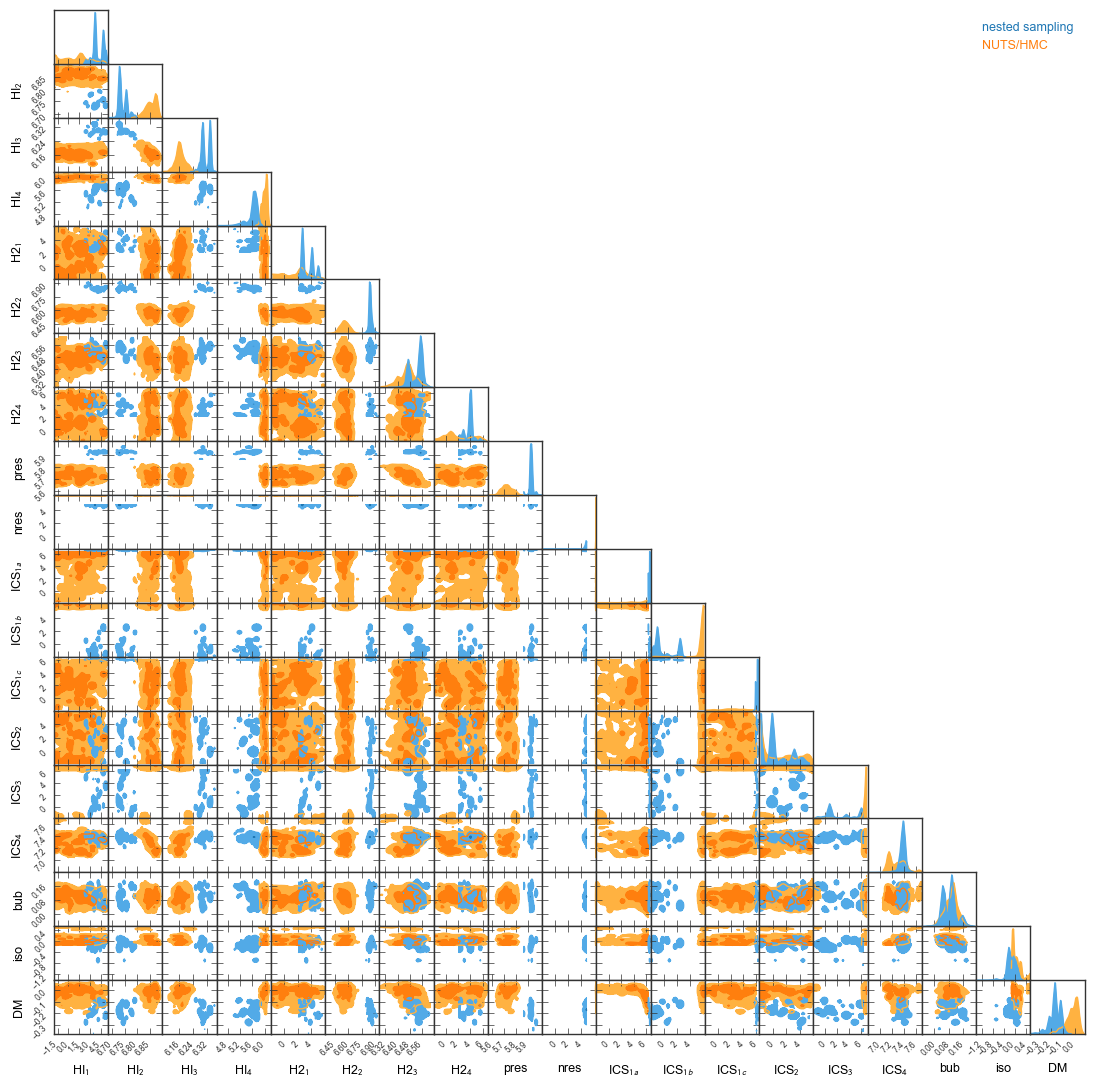

In [28]:
pygtc.plotGTC(chains = [h_sampler_dn.results.samples_equal(), h_samples_nr],
              chainLabels = ['nested sampling', 'NUTS/HMC'],
              paramNames = h_names, #paramRanges = [list(x) for x in bounds[:-1]],
             )
# plt.savefig("/Users/sammcd/Dropbox/bs/0interviews/24/verses_19param_1.pdf", bbox_inches = 'tight')
plt.show()

I'm also defining a function help assess if the posteriors are prior dominated or not (this is just a diagnostic, not necessary for running the rest of the code)

In [41]:
def prior_dominated(samplesT):
    for i in range(len(samplesT)):
        quartile_range = np.percentile(samplesT[i], [25,50,75])
        if (quartile_range[-1] - quartile_range[0] < 0.1) and ((quartile_range[-1] - alt_hm_highpriors[i]>-0.1) or (quartile_range[0] - alt_hm_lowpriors[i]<0.1)):
            print(f"{h_names[i]} component with priors {alt_hm_lowpriors[i]} - {alt_hm_highpriors[i]} has 25/50/75 quantiles of {quartile_range[0]:0.2f}/{quartile_range[1]:0.2f}/{quartile_range[-1]:0.2f}")

In [42]:
prior_dominated(h_samples_nr.T)

nres component with priors -2.0 - 5.0 has 25/50/75 quantiles of 6.29/6.31/6.32


seemingly the only parameter that is prior dominated is `nres`, but we don't want this to be very large, so this is a touchy issue to solve

In [43]:
h_sampler_dn.results.logl[-1] - float(lls_nr.max()), \
float(h_lls_nr.max()) - float(lls_nr.max()), \
float(-h_sampler_nr.last_state.potential_energy) - float(lls_nr.max()), int(h_lls_nr.argmax())

(np.float64(-144.234375), -13.0625, -18.484375, 8569)

the difference between the `numpyro` and `dynesty` posteriors is more pronounced here -- the HMC results lead to tighter constraints, and the log likelihood is substantially higher. Clearly, HMC provides increasing advantages in higher dimensions (though having a good model makes much more of a difference)

## microcanonical Langevin Monte Carlo

This part of the notebook will demonstrate how to use the new [microcanonical Langevin Monte Carlo developed by Robnik and Seljak](https://github.com/JakobRobnik/MicroCanonicalHMC/). This requires us to use smoothed-out priors*, so the likelihood is a little different than in the preceding cases. So I don't think we can exactly compare the `logz` values any more, but it's still instructive to compare the corner plots.

Step one, import `blackjax` and define a `mclmc` sampler.

(*when I tried sampling the same likelihood as with NUTS, I found `nan`s everywhere, so it seems `mchmc` _really_ dislikes hard/uniform/boxy priors for reasons I don't exactly understand)

In [44]:
import blackjax

In [45]:
def run_mclmc(logdensity_fn, num_steps, initial_position, key, transform, desired_energy_variance= 5e-4):
    init_key, tune_key, run_key = jr.split(key, 3)

    # create an initial state for the sampler
    initial_state = blackjax.mcmc.mclmc.init(
        position=initial_position, logdensity_fn=logdensity_fn, rng_key=init_key
    )

    # build the kernel
    kernel = lambda sqrt_diag_cov : blackjax.mcmc.mclmc.build_kernel(
        logdensity_fn=logdensity_fn,
        integrator=blackjax.mcmc.integrators.isokinetic_mclachlan,
        sqrt_diag_cov=sqrt_diag_cov,
    )

    # find values for L and step_size
    (
        blackjax_state_after_tuning,
        blackjax_mclmc_sampler_params,
    ) = blackjax.mclmc_find_L_and_step_size(
        mclmc_kernel=kernel,
        num_steps=num_steps,
        state=initial_state,
        rng_key=tune_key,
        diagonal_preconditioning=False,
        desired_energy_var=desired_energy_variance
    )

    # use the quick wrapper to build a new kernel with the tuned parameters
    sampling_alg = blackjax.mclmc(
        logdensity_fn,
        L=blackjax_mclmc_sampler_params.L,
        step_size=blackjax_mclmc_sampler_params.step_size,
    )

    # run the sampler
    _, samples = blackjax.util.run_inference_algorithm(
        rng_key=run_key,
        initial_state=blackjax_state_after_tuning,
        inference_algorithm=sampling_alg,
        num_steps=num_steps,
        transform=transform,
        progress_bar=True,
    )

    return samples, blackjax_state_after_tuning, blackjax_mclmc_sampler_params, run_key

The API for this is a little different than above, but not terribly so. (Some aspects of the `blackjax` function calls have changed since the earlier versions of this notebook but the performance and external behavior are the same as before.)

In [46]:
from datetime import datetime as dt

In [47]:
ta = dt.now()
mchmcd_samples, initial_state, params, chain_key = run_mclmc(
    logdensity_fn = lambda t: gp.lnlike('hs', jnp.array(t), bin_no=EBIN, ex_num=EXNUM),
    num_steps=10000,
    initial_position = h_sampler_dn.results.samples[-1],
    key=jr.PRNGKey(0),
    transform = lambda x, info: x.position,
)
tb = dt.now()
delt = tb-ta
print(delt)

0:00:23.237919


I'll sample this with three different initial conditions: first using the final point from the `dynesty` results, then with the final point from the `numpyro` results, and finally with all parameter values at the midpoint of the priors (this is not expected to be a good point, but should demonstrate something about sensitivity to initial conditions). I'll include timing information manually to demonstrate the speed (this doesn't seem to have `tqdm` ...yet)

In [48]:
ta = dt.now()
mchmcn_samples, initial_state, params, chain_key =  run_mclmc(
    logdensity_fn = lambda t: gp.lnlike('hs', jnp.array(t), bin_no=EBIN, ex_num=EXNUM),
    num_steps=10000,
    initial_position=h_samples_nr[int(h_lls_nr.argmax())],
    key=jr.PRNGKey(0),
    transform = lambda x, info: x.position,
)
tb = dt.now()
delt = tb-ta
print(delt)

0:00:21.237412


In [49]:
ta = dt.now()
mchmc0_samples, initial_state, params, chain_key =  run_mclmc(
    logdensity_fn = lambda t: gp.lnlike('hs', jnp.array(t), bin_no=5, ex_num=1),
    num_steps=10000,
    initial_position= jnp.array([6., 6., 6., 6., 6., 6., 6., 6., 3., 3., 6., 6., 6., 6., 6., 6., 1., 1., 1.]),
    key=jr.PRNGKey(0),
    transform = lambda x, info: x.position,
)
tb = dt.now()
delt = tb-ta
print(delt)

0:00:23.045231


they all take a similar amount of time, and they're all very fast! Let's plot them all, alongside the previous results. (I'll also throw out half of the poorly initialized `mchmc` results since they're even more spread out otherwise.)

In [50]:
rv = np.array([np.minimum(
                np.percentile(mchmcd_samples, 1, axis=0).T,
                np.percentile(mchmcn_samples, 1, axis=0).T), np.maximum(
                np.percentile(mchmcd_samples, 99, axis=0).T,
                np.percentile(mchmcn_samples, 99, axis=0).T)])

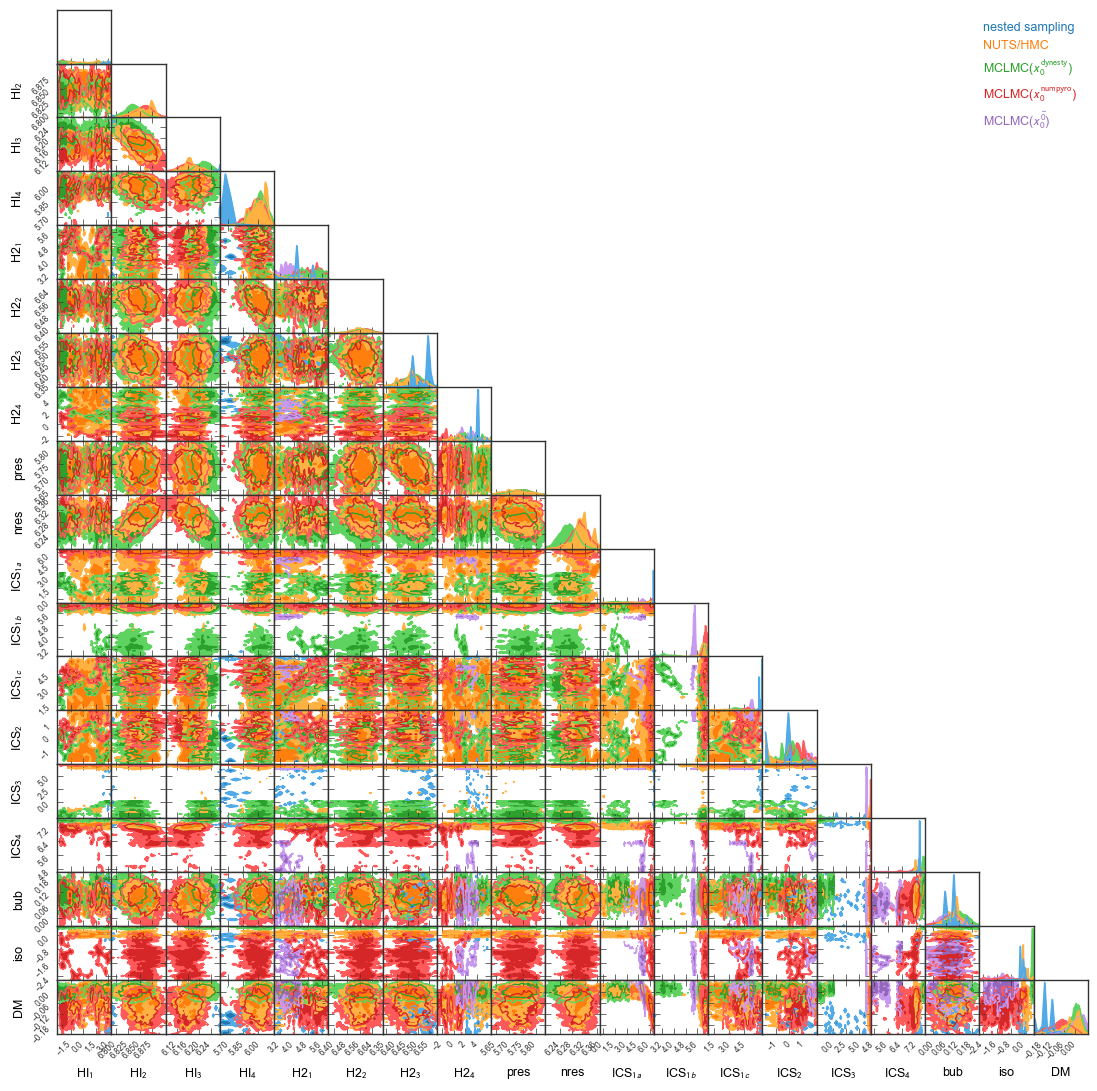

In [54]:
pygtc.plotGTC(chains = [h_sampler_dn.results.samples_equal(), 
                        h_samples_nr,
                        mchmcd_samples, 
                        mchmcn_samples,
                        mchmc0_samples],
              smoothingKernel = 0.1,
              chainLabels = ['nested sampling',
                      'NUTS/HMC',
                             r'MCLMC($x_0^{\rm dynesty}$)',
                             r'MCLMC($x_0^{\rm numpyro}$)',
                  r'MCLMC($x_0^{\vec 0}$)'],
              paramNames = h_names, #paramRanges = [list(x) for x in bounds[:-1]],
              paramRanges = [list(r) for r in rv.T],
             )
# plt.savefig("/Users/sammcd/Downloads/MCLMC_no_prior_compare.pdf", bbox_inches = 'tight')
plt.show()

The posteriors are somewhat broad for the `mclmc` samples, but generally (but by not always) these results overlap with the results from the `numpyro` run. Because I needed to smooth out the priors for `mchmc`, the results for those extend beyond the samples of the other methods and it seems to find more prior-dominated parameters. This suggests that we didn't quite capture the maximum likelihood point in our prior range. So, _in principle_ we should rerun everything with those parameter ranges extended, but this is difficult without leading to `nres` values of O(30%) of the total.

To conclude this comparison, let's see how the log-likelihoods compare at the final points (this time using the `high_smooth` model to put everything on somewhat more equal footing):

In [55]:
np.max([gp.lnlike('high_smooth', s, bin_no=EBIN, ex_num=EXNUM) for s in mchmcd_samples]), \
np.max([gp.lnlike('high_smooth', s, bin_no=EBIN, ex_num=EXNUM) for s in mchmcn_samples]), \
np.max([gp.lnlike('high_smooth', s, bin_no=EBIN, ex_num=EXNUM) for s in mchmc0_samples]), \
np.max([gp.lnlike('high_smooth', s, bin_no=EBIN, ex_num=EXNUM) for s in h_samples_nr]), \
np.max([gp.lnlike('high_smooth', s, EBIN, EXNUM) for s in h_sampler_dn.results.samples]), \
np.max([gp.lnlike('low_smooth', s, EBIN, EXNUM) for s in sampler_dn.results.samples])

(np.float32(-125467.125),
 np.float32(-125453.05),
 np.float32(-170408.17),
 np.float32(-125451.98),
 np.float32(-125583.15),
 np.float32(-125439.64))

# making mock skies and using `sbi`

Here I demonstrate a different way of using `gcepy` for interesting science. In this section, I will use simulation based inference as implemented in the [Macke lab `sbi` package](https://sbi-dev.github.io/sbi/latest/), in particular the sequential neural posterior estimation (SNPE) module, trained on some mock data generated from `gcepy`.

In [56]:
EBIN, EXNUM, PDIM_l, PDIM_h = 9, 1, 5, 19

In [57]:
rng_key, rng_key_ = jr.split(rng_key)

In [58]:
mocks2 = gp.multi_poisson_mock_sky('l', rng_key, 2, jr.normal(rng_key, 5,), EBIN)

In [59]:
ebinedges = [0.275, 0.357, 0.464, 0.603, 0.784, 1.02, 1.32, 1.72, 2.24, 2.91, 3.78, 4.91, 10.8, 23.7, 51.9]
ebincenters = [(ebinedges[i]*ebinedges[i+1])**0.5 for i in range(len(ebinedges)-1)]

Here's an example image. Obviously the edges of the Bubbles are a little non-physical, but the sky elsewhere looks ok

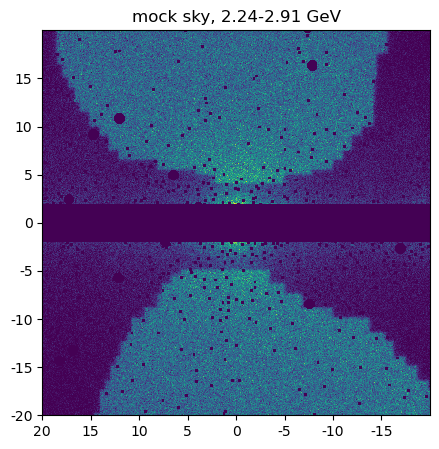

In [60]:
plt.figure(figsize=(5,5))
plt.pcolormesh(mocks2[0][:,::-1])
plt.xticks(np.arange(0,400,50), labels=[f"{int(20-x)}" for x in np.arange(0,400,50)*0.1])
plt.yticks(np.arange(0,400,50), labels=[f"{int(x-20)}" for x in np.arange(0,400,50)*0.1])
plt.title(f"mock sky, {ebinedges[8]}-{ebinedges[9]} GeV")
plt.show()

This is a simple train/test split function that I write myself simply for the purpose of transparency

In [61]:
def tr_te_spl(jr_key, th_X, train_frac = 0.7):
    th_, X_ = th_X
    N = len(X_)
    train_N = int((train_frac/100. if train_frac>1 else train_frac)*N)
    shuf = jr.permutation(jr_key, N)
    ix_tr, ix_te = shuf[:train_N], shuf[train_N:]
    return jnp.array([X_[ix_].flatten() for ix_ in ix_tr]), jnp.array([X_[ix_].flatten() for ix_ in ix_te]), jnp.array([th_[ix_] for ix_ in ix_tr]), jnp.array([th_[ix_] for ix_ in ix_te])

In [62]:
from tqdm.notebook import tqdm, trange
import time

import torch

from sbi.inference import SNPE, prepare_for_sbi, simulate_for_sbi
from sbi.utils.get_nn_models import posterior_nn
from sbi import utils as utils

from sbi.inference.base import infer

This implements the core `sbi` functionality. See the [website](https://sbi-dev.github.io/sbi/latest/) for more details and further options.

In [63]:
class sbi_samps:
    def __init__(self, model, e_bin, ex_num, train_thX = None, test_thX = None, train_frac = 0.7,
                 num_mocks = None,
                 mock_center = (gp.gcepy._hm.pmin+gp.gcepy._hm.pmax)/2,
                 mock_unc = (gp.gcepy._hm.pmax-gp.gcepy._hm.pmin)/2,
                 jr_seed = 0):
        self.inference_obj = SNPE()
        self.time_arr = []
        self.jr_key = jr.PRNGKey(jr_seed)
        self.e_bin, self.model = e_bin, model
        self.mock_center, self.mock_unc = mock_center, mock_unc
        self.p_dim = PDIM_h if 'h' in self.model else PDIM_l
        if train_thX is not None:
            self.train_thX, self.test_thX = train_thX, test_thX
            self.num_tr, self.num_te = len(self.train_thX[0]), len(self.test_thX[0])
            self.num_mocks = self.num_tr + self.num_te
        elif num_mocks is not None:
            self.num_mocks = num_mocks
            self.thX = gp.multi_poisson_mock_sky(self.model, self.jr_key, self.num_mocks,
                                                 self.mock_center, self.e_bin, self.mock_unc,
                                                 return_thetas=True)
            train_X, test_X, train_th, test_th = tr_te_spl(self.jr_key, self.thX, train_frac = train_frac)
            self.train_thX, self.test_thX = (train_th, train_X), (test_th, test_X)
            self.num_tr, self.num_te = len(self.train_thX[0]), len(self.test_thX[0])
        else:
            print("must specify either `num_mocks` or both `train_thX` and `test_thX`")
        _ = self.inference_obj.append_simulations(torch.tensor(np.array(self.train_thX[0]), dtype = torch.float),
                                                  torch.tensor(np.array(self.train_thX[1]), dtype = torch.float))
        self.time_arr.append(time.time())
        
    def train(self):
        _ = self.inference_obj.train()
        self.posterior_obj = self.inference_obj.build_posterior()
        self.time_arr.append(time.time())

    def draw_samps(self, nsamps = 800, num_test = None):
        try:
            self.posterior_obj
        except AttributeError:
            self.train()
        posterior_samp_list = []
        if num_test is None:
            num_test = self.num_te
        for i in tqdm(range(num_test)):
            X_ = torch.tensor(np.array(self.test_thX[1][i]))
            posterior_samples = self.posterior_obj.sample((nsamps,), x=X_,
                                                          show_progress_bars=False)
            posterior_samp_list.append(posterior_samples.numpy())
        # M200_array_test = np.array([self.parent_dict[x]['M200'] for x in self.test_set])
        # redshift_array_test = np.array([self.parent_dict[x]['z'] for x in self.test_set])
        # y0_array_test = np.array([self.parent_dict[x]['y0'] for x in self.test_set])
        self.test_truths = self.test_thX[0]
        self.posterior_samp_array = jnp.array(posterior_samp_list)
        self.time_arr.append(time.time())

    def times(self):
        if len(self.time_arr) == 0:
            return None
        _t = np.array(self.time_arr)[1:] - self.time_arr[0]
        ph_name = ['Training', 'Sampling']
        for i, t in enumerate(_t):
            if t<100:
                print(ph_name[i], f"phase done in {t:0.3} sec. ", end = '')
            else:
                print(ph_name[i], f"phase done in {int(t//60)}:{int(t%60):02}. ", end = '')

First I initialize the `sbi` object with 100 mock sky realizations. Then I train it using labelled training images, and then I draw samples on the held-out test data.

In [64]:
s_l = sbi_samps('l', EBIN, EXNUM, num_mocks=1000,
                mock_center = (gp.gcepy._lm.pmin[:PDIM_l]+gp.gcepy._lm.pmax[:PDIM_l])/2,
                mock_unc = (gp.gcepy._lm.pmax[:PDIM_l]-gp.gcepy._lm.pmin[:PDIM_l])/2)

In [65]:
s_l.train()

 Neural network successfully converged after 63 epochs.

In [66]:
s_l.draw_samps(num_test = 1)

  0%|          | 0/1 [00:00<?, ?it/s]

In [67]:
cmap = plt.get_cmap("tab10")

The results look good in 1D:

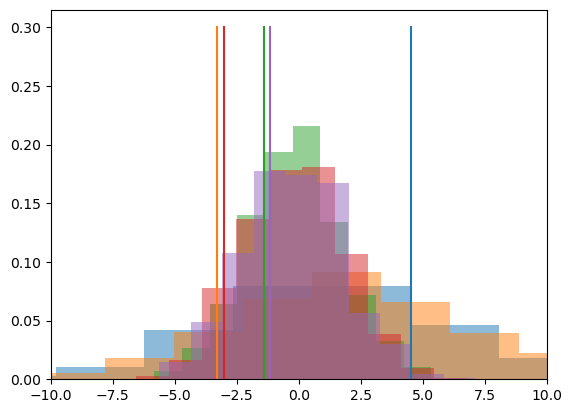

In [68]:
for i in range(len(s_l.posterior_samp_array[0].T)):
    plt.hist(s_l.posterior_samp_array[0].T[i], alpha = 0.5, density = True, color=cmap(i))
    plt.plot([s_l.test_truths[0,i]]*2, [0,.3], color=cmap(i))
# plt.vlines(th_te[0], ymin=0, ymax=1)
plt.xlim(-10,10)
plt.show()

In [69]:
import pygtc
names=['pi+brem', 'ICS', 'bub', 'iso', 'DM']

And the results look good in 2D for one mock test image

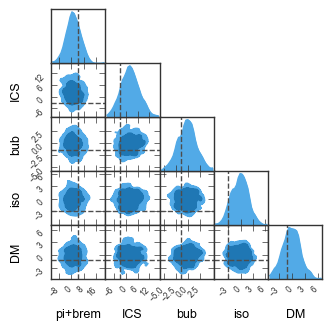

In [70]:
gtc0_l = pygtc.plotGTC(chains = s_l.posterior_samp_array[0],
              # smoothingKernel = 0.1,
#               paramRanges = [(-.35,-.25), (-.15,.05), (-1.2, .4), (-2, 0), (-.2,.2)],
              # chainLabels = ['nested sampling', 'NUTS/HMC'],
              paramNames = names, #paramRanges = [list(x) for x in bounds[:-1]],
                     truths = s_l.test_truths[0]
             )
# plt.savefig("/Users/sammcd/Dropbox/bs/0interviews/24/verses_6param.pdf", bbox_inches = 'tight')

Now I use the trained `sbi` object on the actual Fermi data:

In [71]:
dat_sbi_post = s_l.posterior_obj.sample((1000,), x=torch.tensor(np.array(gp.fermi_dat[EBIN])))

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

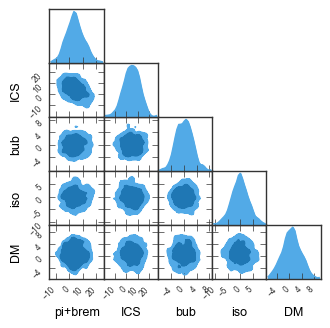

In [72]:
gtcF_l = pygtc.plotGTC(chains = dat_sbi_post,
              # smoothingKernel = 0.1,
#               paramRanges = [(-.35,-.25), (-.15,.05), (-1.2, .4), (-2, 0), (-.2,.2)],
              # chainLabels = ['nested sampling', 'NUTS/HMC'],
              paramNames = names, #paramRanges = [list(x) for x in bounds[:-1]],
             )
# plt.savefig("/Users/sammcd/Dropbox/bs/0interviews/24/verses_6param.pdf", bbox_inches = 'tight')

In [73]:
s_l.times()

Training phase done in 2:56. Sampling phase done in 3:01. 

The training takes about 30 seconds and the sampling for a single point takes about 5 seconds.

Let's do it again for the high-dimensional model:

In [74]:
s_h = sbi_samps('h', EBIN, EXNUM, num_mocks=1000,
                mock_center = (gp.gcepy._hm.pmin[:PDIM_h]+gp.gcepy._hm.pmax[:PDIM_h])/2,
                mock_unc = (gp.gcepy._hm.pmax[:PDIM_h]-gp.gcepy._hm.pmin[:PDIM_h])/2)

In [75]:
s_h.train()

 Neural network successfully converged after 61 epochs.

In [76]:
s_h.draw_samps(num_test = 1)

  0%|          | 0/1 [00:00<?, ?it/s]

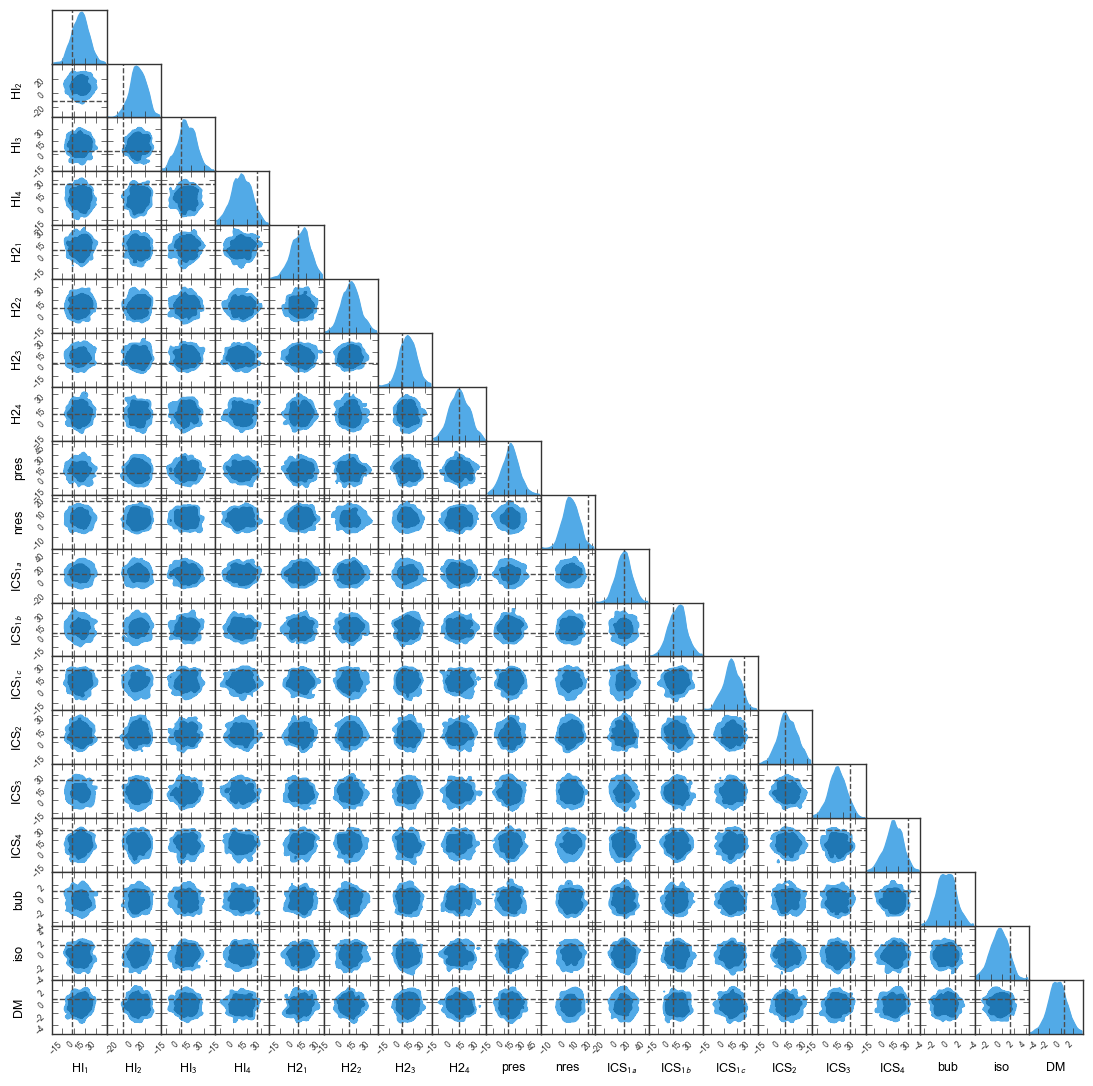

In [77]:
gtc0_h = pygtc.plotGTC(chains = s_h.posterior_samp_array[0],
              # smoothingKernel = 0.1,
#               paramRanges = [(-.35,-.25), (-.15,.05), (-1.2, .4), (-2, 0), (-.2,.2)],
              # chainLabels = ['nested sampling', 'NUTS/HMC'],
              paramNames = h_names, #paramRanges = [list(x) for x in bounds[:-1]],
                     truths = s_h.test_truths[0]
             )
# plt.savefig("/Users/sammcd/Dropbox/bs/0interviews/24/verses_6param.pdf", bbox_inches = 'tight')

In [78]:
dat_sbi_post_h = s_h.posterior_obj.sample((1000,), x=torch.tensor(np.array(gp.fermi_dat[EBIN])))

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

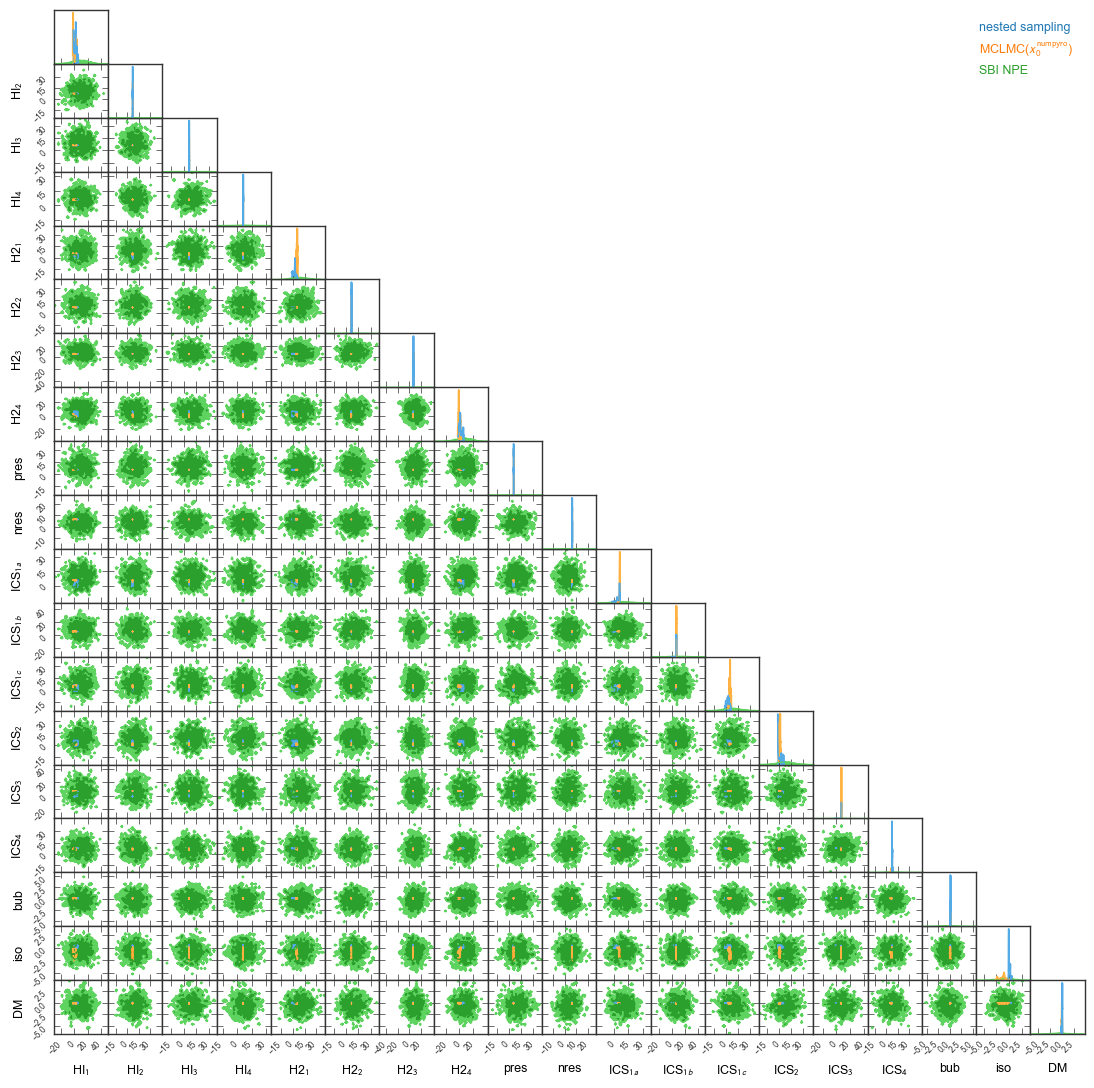

In [79]:
gtcF_h = pygtc.plotGTC(chains = [h_samples_nr,
                                 mchmcn_samples,
                                 dat_sbi_post_h],
              smoothingKernel = 0.1,
              chainLabels = ['nested sampling',
                             r'MCLMC($x_0^{\rm numpyro}$)',
                             r'SBI NPE'],
              paramNames = h_names, #paramRanges = [list(x) for x in bounds[:-1]],
              # paramRanges = [list(r) for r in rv.T],
             )

the results are much wider than the likelihood-based samplers